# QuIP# / AQLM：非相干处理 + 向量量化

> **PTQ 教学 demo 系列 · 05 / 13**
> 配套博客：[《PTQ（05）：QuIP# 与 AQLM》](https://lrypcy.github.io/2026/08/24/ptq-05-quip-aqlm/)（《大模型 PTQ 量化》深度系列 · 第 5 篇）

**一段话原理**：比特压到 2–3 bit 时，「逐元素舍入 + 二阶补偿」（GPTQ/AWQ 路线）逼近信息论极限，QuIP#/AQLM 换了码本路线——让一批权重共享码本、用索引代替数值。其成立依赖两个关键机制：其一 **incoherence processing**——LLM 权重含稀疏巨大离群值，坐标系「病态」；左乘一个随机 Hadamard 旋转 $\tilde W = HW$（工程上以 $O(n\log n)$ 蝶形快速变换实现，$H$ 正交对称故可无损转回）把离群值摊平到所有方向，$\mu$-不相干性 $\mu=\|A\|_\infty\sqrt{mn}/\|A\|_F$ 骤降。其二 **向量量化（VQ）**——把权重按 8 维切块、逐块做 RMS 归一化后在共享码本里查最近码字，每块只存一个短索引（QuIP# 用数学构造的 E8 格码本免训练查表；AQLM 用校准数据训练加性码本），联合编码带来标量量化拿不到的整形增益。本 demo 用纯 numpy 在 $256\times256$ 合成权重上依次验证：旋转救标量量化（误差降一个量级）、块级 RMS 归一的 VQ 天然免疫离群值、同 2-bit 预算下 VQ 显著优于 INT2。

## 第 1 步 · 工具箱：快速 Walsh-Hadamard 变换（蝶形）

这步在做什么：导入 numpy 与 matplotlib 并固定 SEED=0；实现全篇唯一的「重计算」——$O(n\log n)$ 蝶形快速 Hadamard 变换。它就是 QuIP 随机旋转的全部成本：真正的随机性只需 $n$ 个 $\pm1$ 符号的对角阵 $D$（论文取 $R=HD/\sqrt n$，本 demo 取 $D=I$ 不影响结论），$H$ 本身不用存储。末尾自检两条数学性质——正交（$HH^\top=I$，旋转能量守恒）与对称（$H^\top=H$，转回去零成本），这是后面「量化完再转回原坐标系评估」合法性的前提。

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

SEED = 0          # 全局随机种子: 全部结果可复现
K = N = 256       # 权重形状 K x N, 边长须为 2 的幂才能做 Hadamard 旋转
RANK = 16         # 低秩骨架的秩(复刻真实权重谱集中的特点)
OUT_FRAC = 0.02   # 稀疏大值元素的比例
OUT_MAG = 8.0     # 稀疏大值的倍数
V_BLK = 8         # VQ 码字维度(QuIP#/AQLM 的 8 维分块)
N_CENT = 256      # 码字个数: 每个 8 维块只需存 log2(256)=8 bit 索引
BITS_LIST = (2, 3, 4)


def fast_wht(x):
    """沿最后一维做归一化 Walsh-Hadamard 变换(蝶形算法), n 须为 2 的幂."""
    n = x.shape[-1]
    h = x.astype(np.float64).copy()
    step = 1
    while step < n:
        h = h.reshape(-1, step, 2, n // (step * 2))   # 切出相邻蝶形对
        a = h[:, :, 0, :].copy()
        b = h[:, :, 1, :].copy()
        h[:, :, 0, :] = a + b                         # 蝶形: (a,b) -> (a+b, a-b)
        h[:, :, 1, :] = a - b
        h = h.reshape(-1, n)
        step *= 2   # 坑: 蝶形跨度必须翻倍, 漏掉这句 while 永不终止 -> 内存溢出
    return (h / np.sqrt(n)).reshape(x.shape)


def rel_fro(a, b):
    """相对 Frobenius 误差 ||a-b||_F / ||b||_F."""
    return float(np.linalg.norm(a - b) / np.linalg.norm(b))


def incoherence(A):
    """mu-incoherence: 最大绝对元素相对均方根幅度的倍数, 越小越不相干."""
    return float(np.abs(A).max() * np.sqrt(A.size) / np.linalg.norm(A))


H = fast_wht(np.eye(K))
print("正交性 max|H@H-I| = %.2e ; 对称性 max|H-H^T| = %.2e"
      % (np.abs(H @ H - np.eye(K)).max(), np.abs(H - H.T).max()))

正交性 max|H@H-I| = 0.00e+00 ; 对称性 max|H-H^T| = 0.00e+00


## 第 2 步 · 合成数据与不相干性度量

这步在做什么：构造 toy 规模的病态权重——rank-16 低秩骨架叠加 2%、×8 倍的稀疏大值，复刻真实 LLM 权重「谱集中 + 少数巨大离群元」的两个关键特征；随后按博客 §2.2 的定义计算 $\mu$-不相干性，并把旋转前后元素幅值的降序分布画在一起：原始域长尾触目（少数元素比典型值大一个量级），一次 Hadamard 旋转后整条曲线被压平——这就是「不相干」的直观含义，也是后续一切量化器能好好工作的前提。

W: 256x256, rank-16 低秩骨架, 1272 个 x8 稀疏大值
mu-incoherence: raw = 20.21 -> rotated = 4.78  (降低 4.2 倍)


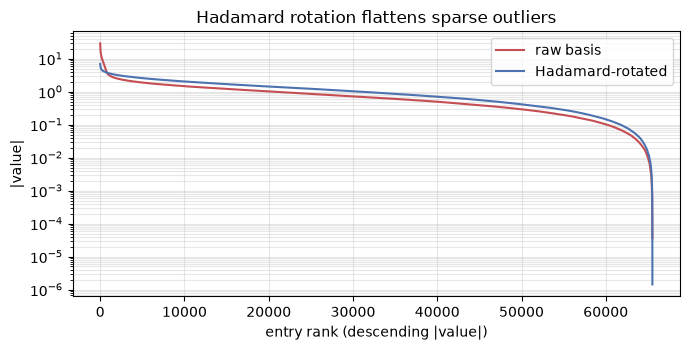

In [2]:
def make_weight(with_outliers=True):
    """合成权重: 低秩骨架 + 稀疏大值; with_outliers=False 用于 sanity 对照."""
    rng = np.random.default_rng(SEED)
    W = rng.standard_normal((K, RANK)) @ rng.standard_normal((RANK, N)) / np.sqrt(RANK)
    mask = rng.random((K, N)) < OUT_FRAC
    if with_outliers:
        W[mask] *= OUT_MAG
    return W, mask


W, out_mask = make_weight()
Wr = H @ W                        # QuIP 的核心一步: 左乘 H 进入不相干坐标系
print(f"W: {K}x{N}, rank-{RANK} 低秩骨架, "
      f"{int(out_mask.sum())} 个 x{OUT_MAG:.0f} 稀疏大值")

mu_w, mu_wr = incoherence(W), incoherence(Wr)
print(f"mu-incoherence: raw = {mu_w:.2f} -> rotated = {mu_wr:.2f}"
      f"  (降低 {mu_w / mu_wr:.1f} 倍)")

fig, ax = plt.subplots(figsize=(7.0, 3.6))
ax.semilogy(np.sort(np.abs(W).ravel())[::-1],
            color="#C44E52", label="raw basis")
ax.semilogy(np.sort(np.abs(Wr).ravel())[::-1],
            color="#4C72B0", label="Hadamard-rotated")
ax.set_xlabel("entry rank (descending |value|)")
ax.set_ylabel("|value|")
ax.set_title("Hadamard rotation flattens sparse outliers")
ax.legend()
ax.grid(alpha=0.3, which="both")
fig.tight_layout()
plt.show()

## 第 3 步 · 对照实验：标量量化在旋转前后的命运

这步在做什么：用最普通的逐张量对称 INT2/3/4 网格（step 由全局 $\max|W|$ 决定）分别量化原始域 $W$ 与旋转域 $W_r$，后者量化完再用 $H$ 转回原坐标系评估。预期复现博客 §1 的论断：逐张量网格的 step 被离群值绑架，普通元素的精度被牺牲殆尽；旋转摊平离群值后，同一个量化器的误差直降一个量级——**incoherence processing 救的是标量路线**。

In [3]:
def scalar_quant_tensor(M, bits):
    """逐张量对称标量量化(mid-rise 网格): 电平 = {+-0.5, +-1.5, ...} * step."""
    n_half = 2 ** (bits - 1)
    amax = np.max(np.abs(M))                 # step 被 amax 绑架 -- outlier 的原罪
    step = amax / n_half
    idx = np.clip(np.round((np.abs(M) - step / 2) / step), 0, n_half - 1)
    return np.sign(M) * (idx + 0.5) * step


sq_rows = []
print(f"{'method':>6} {'err(raw)':>9} {'err(rot)':>9}")
for b in BITS_LIST:
    e_raw = rel_fro(scalar_quant_tensor(W, b), W)
    # 旋转域量化的评估姿势: H 正交对称 => 再左乘一次 H 即转回原坐标系
    e_rot = rel_fro(H @ scalar_quant_tensor(Wr, b), W)
    sq_rows.append({"method": f"INT{b}", "bpw": b,
                    "err_raw": e_raw, "err_rot": e_rot})
    print(f"{'INT' + str(b):>6} {e_raw:9.4f} {e_rot:9.4f}"
          f"   ({100 * (1 - e_rot / e_raw):.0f}% down)")


method  err(raw)  err(rot)
  INT2    4.5019    0.7129   (84% down)
  INT3    2.0177    0.3441   (83% down)
  INT4    0.8350    0.1722   (79% down)


## 第 4 步 · 方法核心：块级向量量化（码本查表重构）

这步在做什么：实现 AQLM/QuIP# 风格的最小 VQ 三件套——(a) 把矩阵每一列按 8 个输出通道切成 8 维码字块；(b) **逐块 RMS 归一化后再匹配**：每个离群块自带尺度，不再绑架全局码本，这是 AQLM 与 QuIP# 共同的关键设计；(c) 用 kmeans++ 初始化 + Lloyd 迭代在归一化空间学一个 256 词的全局码本，每块匹配最近码字后乘回 RMS 重构——解码即一次查表。两个必踩坑已内置防御：重构 reshape 必须按 `transpose(1, 2, 0).reshape(K, N)` 的轴序摆回；跑正式数据前先在无 outlier 的高斯低秩矩阵上做 sanity（断言相对误差 <0.5），确认轴序与归一化无误。

In [4]:
def _sq_dists(Xtr, cent):
    """成对平方距离 ||x-c||^2, 内积展开避免 (n, S, v) 大中间张量."""
    return ((Xtr ** 2).sum(1)[:, None]
            + (cent ** 2).sum(1)[None, :] - 2.0 * Xtr @ cent.T)


def kmeans(Xtr, n_cent, iters=15, seed=SEED + 1):
    """kmeans++ 初始化 + Lloyd 迭代: AQLM 学码本的最小内核."""
    rg = np.random.default_rng(seed)
    n = Xtr.shape[0]
    cent = np.empty((n_cent, Xtr.shape[1]))
    cent[0] = Xtr[rg.integers(n)]            # kmeans++: 按 D^2 概率逐个撒点
    d2 = np.sum((Xtr - cent[0]) ** 2, axis=1)
    for i in range(1, n_cent):
        p = np.maximum(d2, 0)
        cent[i] = Xtr[rg.choice(n, p=p / p.sum())]
        d2 = np.minimum(d2, np.sum((Xtr - cent[i]) ** 2, axis=1))
    assign = None
    for _ in range(iters):                   # Lloyd: 分配 -> 更新, 不动点即停
        new_assign = _sq_dists(Xtr, cent).argmin(1)
        if assign is not None and np.array_equal(new_assign, assign):
            break
        assign = new_assign
        for k in range(n_cent):
            m = assign == k
            if m.any():
                cent[k] = Xtr[m].mean(axis=0)
    return cent


def vector_quant_scaled(M, v, n_cent):
    """块级 VQ: 列切 v 维码字 -> 逐块 RMS 归一 -> 匹配全局码本 -> 乘回重构."""
    Nb = M.shape[1]
    flat = M.T.reshape(Nb, -1, v).reshape(-1, v)      # (Nb, K//v, v) 展平成码字流
    rms = np.sqrt(np.mean(flat ** 2, axis=1, keepdims=True)) + 1e-12
    u = flat / rms                    # 关键: 先归一再匹配, 离群块自带尺度
    cent = kmeans(u, n_cent)          # 码本在归一化空间中学习
    outu = cent[_sq_dists(u, cent).argmin(1)]         # 最近码字即查表重构
    rec_blocks = (outu * rms).reshape(Nb, -1, v)      # (Nb, K//v, v)
    # 坑: transpose(1,2,0) 把 (blk, c, col) 摆成 col 最内层, reshape 才能对齐 W
    return rec_blocks.transpose(1, 2, 0).reshape(K, N)


t0 = time.time()
Wg, _ = make_weight(with_outliers=False)              # 无 outlier 高斯低秩对照
err_gauss = rel_fro(vector_quant_scaled(Wg, V_BLK, N_CENT), Wg)
assert err_gauss < 0.5, "sanity failed: reshape 轴序或 RMS 归一化有误"
print(f"sanity: 无 outlier 高斯低秩矩阵 VQ 相对误差 = {err_gauss:.4f} < 0.5"
      f"  [{time.time() - t0:.1f}s]")

sanity: 无 outlier 高斯低秩矩阵 VQ 相对误差 = 0.4888 < 0.5  [0.5s]


## 第 5 步 · 误差评估：旋转前后 VQ 对比与全景汇总

这步在做什么：先算清存储账——每个 8 维块存 1 个 8 bit 码字索引 + 1 个 8 bit 块尺度，合计约 2 bit/权重，与 INT2 同预算，对比才公平；随后把同一个 VQ 分别跑在原始域与旋转域，和第 3 步的标量结果一起画进对数坐标柱状图，回答本篇的核心问题：**码本路线还需要旋转吗？**

VQ 存储: 每 8 维块 = 8 bit 索引 + 8 bit 尺度 -> 约 2.00 bit/权重


VQ v=8 C=256: raw = 0.3927 | rotated = 0.4830  [0.8s]
同 2-bit 预算(旋转基): VQ 0.4830 vs INT2 0.7129 -> 好 +32.2%


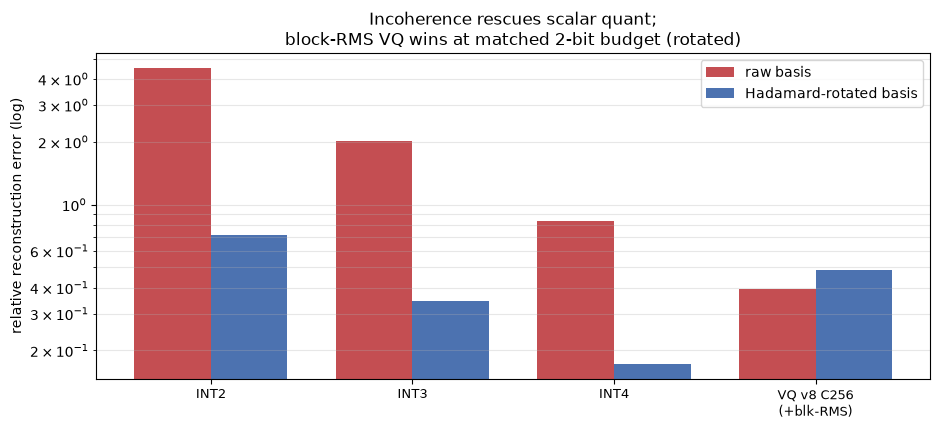

In [5]:
idx_bits = int(np.log2(N_CENT))          # 每个 8 维块的索引位数
scale_bits = 8                           # 每块一个 8bit RMS 尺度(简化假设)
bpw = (idx_bits + scale_bits) / V_BLK
print(f"VQ 存储: 每 {V_BLK} 维块 = {idx_bits} bit 索引 + {scale_bits} bit 尺度"
      f" -> 约 {bpw:.2f} bit/权重")

t0 = time.time()
e_vq_raw = rel_fro(vector_quant_scaled(W, V_BLK, N_CENT), W)
e_vq_rot = rel_fro(H @ vector_quant_scaled(Wr, V_BLK, N_CENT), W)
print(f"VQ v={V_BLK} C={N_CENT}: raw = {e_vq_raw:.4f} | rotated = "
      f"{e_vq_rot:.4f}  [{time.time() - t0:.1f}s]")
gain = -100 * (e_vq_rot - sq_rows[0]["err_rot"]) / sq_rows[0]["err_rot"]
print(f"同 2-bit 预算(旋转基): VQ {e_vq_rot:.4f} vs INT2 "
      f"{sq_rows[0]['err_rot']:.4f} -> 好 {gain:+.1f}%")

labels = [r["method"] for r in sq_rows] + ["VQ v8 C256\n(+blk-RMS)"]
raw_vals = [r["err_raw"] for r in sq_rows] + [e_vq_raw]
rot_vals = [r["err_rot"] for r in sq_rows] + [e_vq_rot]
x = np.arange(len(labels))
wd = 0.38
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.bar(x - wd / 2, raw_vals, wd, color="#C44E52", label="raw basis")
ax.bar(x + wd / 2, rot_vals, wd, color="#4C72B0",
       label="Hadamard-rotated basis")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("relative reconstruction error (log)")
ax.set_title("Incoherence rescues scalar quant;\n"
             "block-RMS VQ wins at matched 2-bit budget (rotated)")
ax.legend()
ax.grid(axis="y", alpha=0.3, which="both")
fig.tight_layout()
plt.show()

## 结果解读与方法局限

**结果解读**（以下为 SEED=0 实测输出，与同目录 `run.py` 的 `results/results.json` 同量级）：

- **旋转打散异常结构**：$\mu$-不相干性从 raw 域的 **20.21** 降到旋转域的 **4.78**（×4.2）；幅值分布图上，2% 稀疏大值拖出的长尾被压成一条平缓曲线——outlier 从「个别元素的性质」变成「所有元素均匀分摊的小扰动」。
- **标量量化被 outlier 绑架、被旋转拯救**：逐张量 INT2 相对误差 raw **4.5019** → 旋转 **0.7129**（↓84%）；INT3 ↓83%、INT4 ↓79%。同一个量化器，只换坐标系就差出一个数量级——位宽越低，旋转的相对收益越大。
- **VQ 实现自证正确**：无 outlier 高斯低秩矩阵上相对误差 **0.4888 < 0.5**，断言通过，`transpose(1,2,0)` 轴序与逐块 RMS 归一无误。
- **块级 VQ 本身免疫 outlier**：raw 域误差 **0.3927** 已低于全部标量配置——每块自带 RMS 尺度，码本在归一化空间里只看「形状」不看「幅度」。旋转域 **0.4830** 反而略升：rank-16 骨架让原始行的 8 维块保有可聚类的结构，旋转把这种结构搅散了。**结论：归一化救码本、旋转救标量，两者不必叠加。**
- **同预算对决（≈2 bit/权重，旋转基）**：VQ **0.4830** vs INT2 **0.7129**，好 **32.2%**——8 维联合编码的整形增益是实打实的，这正是博客 §1.2「同样 16 bit，联合编码词汇量 ×4」的直接验证。

**方法局限**：

- **toy 规模、无 Hessian 加权**：真实 QuIP#/AQLM 最小化的是校准集上的输出误差 $\mathrm{tr}(\Delta^\top H\Delta)$，且 AQLM 以 GPTQ 结果初始化码本；本 demo 只做权重域 MSE，是精度下界的示意。
- **未实现 E8 格码本**：demo 的码本是 kmeans 学出来的（AQLM 路线）；QuIP# 免训练格码本的精髓——解析最近格点算法与 theta 级数定码本半径——这里没有覆盖。
- **码本开销未摊销**：$256\times8$ 的码本本身要占内存，矩阵越大摊销越小；真实系统还需处理 bit 打包与查表 kernel（gather 无法直接映射到 tensor core，这正是码本路线工程生态滞后的根源）。
- **结论不可直接外推**：LLM 权重的 outlier 强度与 Hessian 病态程度远超 toy 分布，但定性结论不变——**极低位宽的正确姿势 = 旋转/归一化处理坐标系 + 码本联合编码**。